In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data_clean/merged_returns.csv')
df['Date'] = pd.to_datetime(df['Date'])

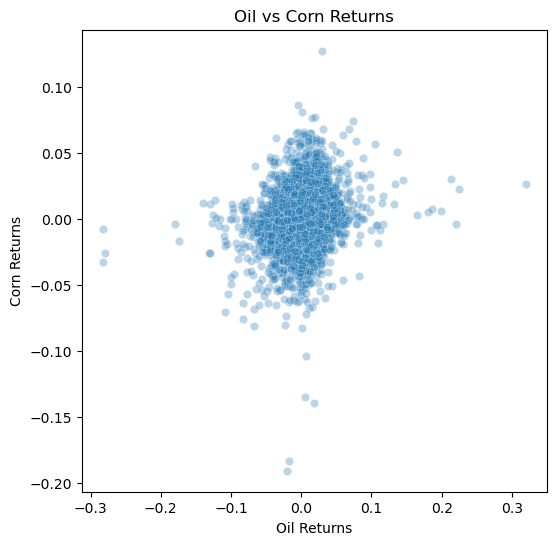

In [3]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=df['Oil_ret'], y=df['Corn_ret'], alpha = 0.3)
plt.title("Oil vs Corn Returns")
plt.xlabel("Oil Returns")
plt.ylabel("Corn Returns")
plt.show()

In [4]:
df[['Oil_ret','Corn_ret']].corr()

,Oil_ret,Corn_ret
Oil_ret,1.000000,0.190661
Corn_ret,0.190661,1.000000


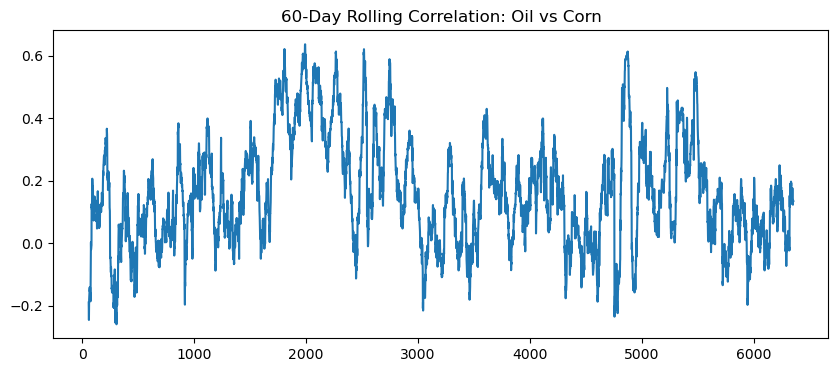

In [5]:
rolling_corr_oc = df['Oil_ret'].rolling(60).corr(df['Corn_ret'])

rolling_corr_oc.plot(figsize=(10,4))
plt.title("60-Day Rolling Correlation: Oil vs Corn")
plt.show()

In [6]:
threshold = df['Oil_ret'].abs().quantile(0.95)
df['Oil_shock'] = df['Oil_ret'].abs() > threshold

In [7]:
df.groupby('Oil_shock')['Corn_ret'].mean()

Oil_shock
False    0.000283
True    -0.001802
Name: Corn_ret, dtype: float64

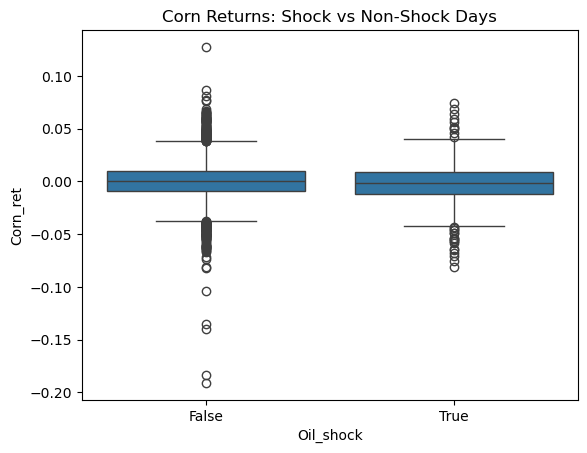

In [8]:
sns.boxplot(x=df['Oil_shock'], y=df['Corn_ret'])
plt.title("Corn Returns: Shock vs Non-Shock Days")
plt.show()

In [10]:
df['Oil_vol'] = df['Oil_ret'].rolling(3).std()

In [11]:
vol_threshold = df['Oil_vol'].median()
df['High_vol'] = df['Oil_vol'] > vol_threshold

In [12]:
high_vol_corr = df[df['High_vol']][['Oil_ret','Corn_ret']].corr().iloc[0,1]
low_vol_corr = df[~df['High_vol']][['Oil_ret','Corn_ret']].corr().iloc[0,1]

print("High Volume Correlation:", high_vol_corr)
print("Low Volume Correlation:", low_vol_corr)

High Volume Correlation: 0.23816107165486086
Low Volume Correlation: 0.11360609177447736


In [13]:
df['OilGas_corr'] = df['Oil_ret'].rolling(30).corr(df['Gas_ret'])

In [14]:
corr_threshold = df['OilGas_corr'].median()
df['High_link'] = df['OilGas_corr'] > corr_threshold

In [16]:
high_link_corr = df[df['High_link']][['Oil_ret','Corn_ret']].corr().iloc[0,1]
low_link_corr = df[~df['High_link']][['Oil_ret','Corn_ret']].corr().iloc[0,1]

print("High Link Correlation:", high_link_corr)
print("Low Link Correlation:", low_link_corr)

High Link Correlation: 0.207579332041531
Low Link Correlation: 0.17360786102061976


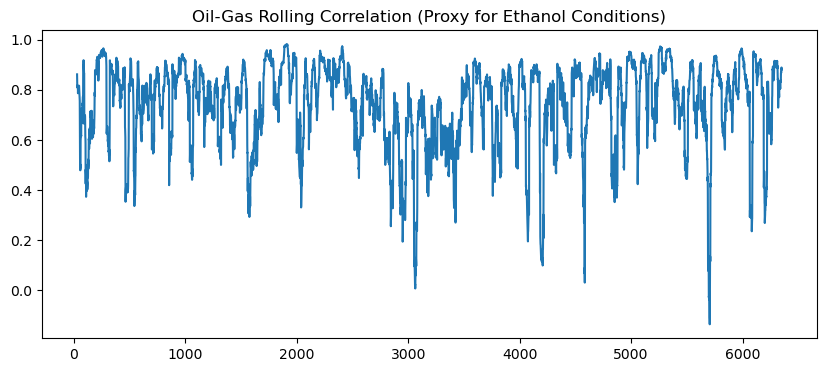

In [17]:
plt.figure(figsize=(10,4))
df['OilGas_corr'].plot()
plt.title("Oil-Gas Rolling Correlation (Proxy for Ethanol Conditions)")
plt.show()

In [18]:
df[['Oil_ret','Corn_ret']].describe()
df.isna().sum()

Date             0
Oil              0
Corn             0
Gasoline         0
Oil_ret          0
Corn_ret         0
Gas_ret          0
Gasoline_ret     0
Oil_shock        0
Oil_vol          2
High_vol         0
OilGas_corr     29
High_link        0
dtype: int64

In [19]:
df.groupby('Oil_shock')['Corn_ret'].std()

Oil_shock
False    0.017352
True     0.022880
Name: Corn_ret, dtype: float64

In [22]:
df['Corn_abs'] = df['Corn_ret'].abs()

df.groupby('Oil_shock')['Corn_abs'].mean()
df.groupby('Oil_shock')['Corn_ret'].std()

Oil_shock
False    0.017352
True     0.022880
Name: Corn_ret, dtype: float64

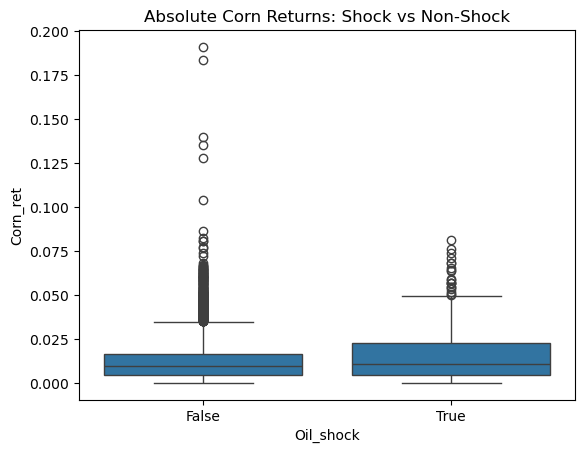

In [23]:
sns.boxplot(x=df['Oil_shock'], y=df['Corn_ret'].abs())
plt.title("Absolute Corn Returns: Shock vs Non-Shock")
plt.show()

In [28]:
high_thresh = df['OilGas_corr'].quantile(0.75)
low_thresh = df['OilGas_corr'].quantile(0.25)

high_link = df[df['OilGas_corr'] > high_thresh]
low_link = df[df['OilGas_corr'] < low_thresh]

In [30]:
high_link_corr = high_link[['Oil_ret','Corn_ret']].corr().iloc[0,1]
low_link_corr  = low_link[['Oil_ret','Corn_ret']].corr().iloc[0,1]

print("High Link Correlation:", high_link_corr)
print("Low Link Correlation:", low_link_corr)

High Link Correlation: 0.22677190695521235
Low Link Correlation: 0.13693450774545704


In [31]:
print("High Link N:", len(high_link))
print("Low Link N:", len(low_link))

High Link N: 1581
Low Link N: 1581


In [32]:
high_link['Corn_ret'].abs().mean()
low_link['Corn_ret'].abs().mean()

np.float64(0.011859159728608277)

In [33]:
high_link['Corn_ret'].std()
low_link['Corn_ret'].std()

0.016542645123936498

In [34]:
df = df.dropna(subset=['Oil_vol','OilGas_corr'])

In [35]:
df[['Oil_ret','Corn_ret']].describe()
df.isna().sum()

Date            0
Oil             0
Corn            0
Gasoline        0
Oil_ret         0
Corn_ret        0
Gas_ret         0
Gasoline_ret    0
Oil_shock       0
Oil_vol         0
High_vol        0
OilGas_corr     0
High_link       0
Corn_abs        0
dtype: int64

In [36]:
high_link['Corn_ret'].abs().mean()
low_link['Corn_ret'].abs().mean()

high_link['Corn_ret'].std()
low_link['Corn_ret'].std()

0.016542645123936498

In [37]:
print("High Link Abs:", high_link['Corn_ret'].abs().mean())
print("Low Link Abs:", low_link['Corn_ret'].abs().mean())

print("High Link Std:", high_link['Corn_ret'].std())
print("Low Link Std:", low_link['Corn_ret'].std())

High Link Abs: 0.01296604419200128
Low Link Abs: 0.011859159728608277
High Link Std: 0.017695487936339162
Low Link Std: 0.016542645123936498


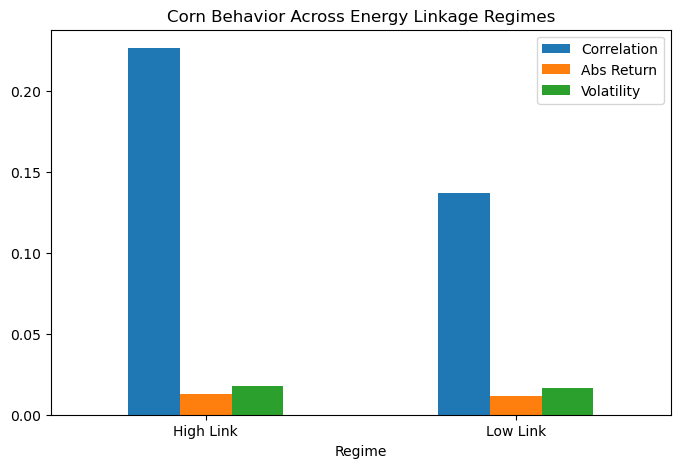

In [40]:
import pandas as pd

regime_df = pd.DataFrame({
    'Regime': ['High Link', 'Low Link'],
    'Correlation': [high_link_corr, low_link_corr],
    'Abs Return': [high_link['Corn_ret'].abs().mean(), low_link['Corn_ret'].abs().mean()],
    'Volatility': [high_link['Corn_ret'].std(), low_link['Corn_ret'].std()]
})

regime_df.set_index('Regime').plot(kind='bar', figsize=(8,5))
plt.title("Corn Behavior Across Energy Linkage Regimes")
plt.xticks(rotation=0)
plt.show()